### EDA 1
#### Bike Details Dataset

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib as plt
import warnings
warnings.filterwarnings('ignore')

In [4]:
#Current directory
import os
print(os.getcwd())

C:\Users\ITProFound_Hyd_024\Pw data science\Assignment


In [5]:
# Bike Details Dataset
df = pd.read_csv(r"../Dataset/BIKE DETAILS.csv")
df


,name,selling_price,year,seller_type,owner,km_driven,ex_showroom_price
0,Royal Enfield Classic 350,175000,2019,Individual,1st owner,350,NaN
1,Honda Dio,45000,2017,Individual,1st owner,5650,NaN
2,Royal Enfield Classic Gunmetal Grey,150000,2018,Individual,1st owner,12000,148114.0
3,Yamaha Fazer FI V 2.0 [2016-2018],65000,2015,Individual,1st owner,23000,89643.0
4,Yamaha SZ [2013-2014],20000,2011,Individual,2nd owner,21000,NaN
...,...,...,...,...,...,...,...
1056,Activa 3g,17000,2010,Individual,1st owner,500000,52000.0
1057,Honda CB twister,16000,2012,Individual,1st owner,33000,51000.0
1058,Bajaj Discover 125,15000,2013,Individual,2nd owner,35000,57000.0
1059,Honda CB Shine,12000,2009,Individual,1st owner,53000,58000.0


In [6]:
df.tail()

,name,selling_price,year,seller_type,owner,km_driven,ex_showroom_price
1056,Activa 3g,17000,2010,Individual,1st owner,500000,52000.0
1057,Honda CB twister,16000,2012,Individual,1st owner,33000,51000.0
1058,Bajaj Discover 125,15000,2013,Individual,2nd owner,35000,57000.0
1059,Honda CB Shine,12000,2009,Individual,1st owner,53000,58000.0
1060,Bajaj Pulsar 150,10000,2008,Individual,1st owner,92233,75000.0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1061 entries, 0 to 1060
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   name               1061 non-null   object 
 1   selling_price      1061 non-null   int64  
 2   year               1061 non-null   int64  
 3   seller_type        1061 non-null   object 
 4   owner              1061 non-null   object 
 5   km_driven          1061 non-null   int64  
 6   ex_showroom_price  626 non-null    float64
dtypes: float64(1), int64(3), object(3)
memory usage: 58.2+ KB


#### What is the range of selling prices in the dataset?

In [9]:
# Get the range of selling prices
min_price = df["selling_price"].min()
max_price = df["selling_price"].max()

print(f'Minimum selling price is :- {min_price}') 
print(f'Maximum selling price is :- {max_price}') 


Minimum selling price is :- 5000
Maximum selling price is :- 760000


#### What is the median selling price for bikes in the dataset?

In [11]:
median_price = df["selling_price"].median()
print(f'Median selling price is :- {median_price}')  

Median selling price is :- 45000.0


#### What is the most common seller type

In [13]:
print(f'Most common seller type is :- {df.seller_type.value_counts().idxmax()}')

Most common seller type is :- Individual


####  How many bikes have driven more than 50,000 kilometers

In [15]:
df[df.km_driven>=50000].shape[0]


207

#### What is the average km_driven value for each ownership type

In [17]:
avg_km_by_owner = df.groupby("owner")["km_driven"].mean()
avg_km_by_owner

owner
1st owner     32816.583333
2nd owner     39288.991870
3rd owner     33292.181818
4th owner    311500.000000
Name: km_driven, dtype: float64

#### What proportion of bikes are from the year 2015 or older

In [19]:
bikes_2015_or_older = df[df["year"] <= 2015].shape[0]

# Calculate the proportion
total_bikes = df.shape[0]
proportion_2015_or_older = bikes_2015_or_older / total_bikes

print(f'proportion_2015_or_older is :- {proportion_2015_or_older}')

proportion_2015_or_older is :- 0.5664467483506126


#### What is the trend of missing values across the dataset

In [21]:
# Check for missing values in each column
missing_values = df.isnull().sum()

# Calculate the percentage of missing values
missing_percentage = (missing_values / df.shape[0]) * 100

# Combine into a DataFrame for better visualization
missing_data_summary = pd.DataFrame({"Missing Values": missing_values, "Percentage (%)": missing_percentage})
missing_data_summary


,Missing Values,Percentage (%)
name,0,0.000000
selling_price,0,0.000000
year,0,0.000000
seller_type,0,0.000000
owner,0,0.000000
km_driven,0,0.000000
ex_showroom_price,435,40.999057


#### What is the highest ex_showroom_price recorded, and for which bike

In [23]:
df.head(1)

,name,selling_price,year,seller_type,owner,km_driven,ex_showroom_price
0,Royal Enfield Classic 350,175000,2019,Individual,1st owner,350,NaN


In [24]:
max_ex_showroom_price = df['ex_showroom_price'].max()
bike_with_max_price = df[df["ex_showroom_price"] == max_ex_showroom_price][["name", "ex_showroom_price"]]
bike_with_max_price


,name,ex_showroom_price
134,Harley-Davidson Street Bob,1278000.0


#### What is the total number of bikes listed by each seller type

In [26]:
total_bikes_each_seller = df["seller_type"].value_counts()
total_bikes_each_seller

seller_type
Individual    1055
Dealer           6
Name: count, dtype: int64

#### What is the relationship between selling_price and km_driven for first-owner bikes

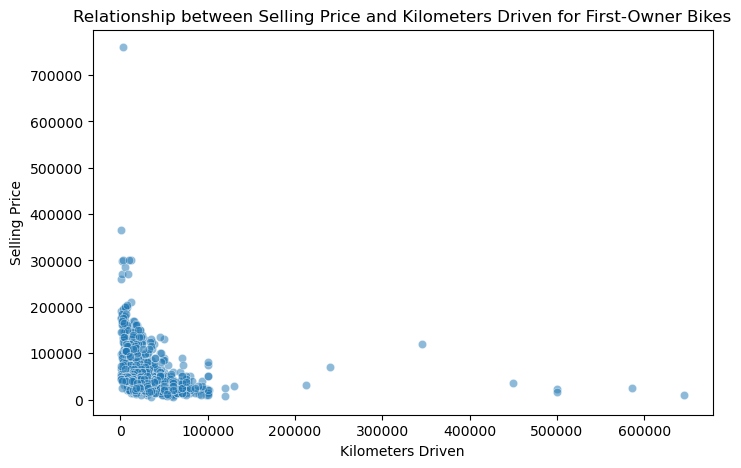

-0.24348174844965736

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter data for first-owner bikes
first_owner_bikes = df[df["owner"] == "1st owner"]

# Scatter plot to visualize the relationship
plt.figure(figsize=(8, 5))
sns.scatterplot(data=first_owner_bikes, x="km_driven", y="selling_price", alpha=0.5)
plt.xlabel("Kilometers Driven")
plt.ylabel("Selling Price")
plt.title("Relationship between Selling Price and Kilometers Driven for First-Owner Bikes")
plt.show()

# Compute correlation coefficient
correlation = first_owner_bikes["km_driven"].corr(first_owner_bikes["selling_price"])
correlation


Observation:-
The scatter plot shows a weak negative correlation between selling price and kilometers driven for first-owner bikes. The correlation coefficient is -0.24, indicating a slight tendency for bikes with higher kilometers driven to have lower selling prices, but the relationship is not strong.

####  Identify and remove outliers in the km_driven column using the IQR method

In [31]:
# Calculate Q1, Q3, and IQR for km_driven
Q1 = df["km_driven"].quantile(0.25)
Q3 = df["km_driven"].quantile(0.75)
IQR = Q3 - Q1

# Define lower and upper bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter out outliers
df_filtered = df[(df["km_driven"] >= lower_bound) & (df["km_driven"] <= upper_bound)]

# Number of rows removed
num_removed = df.shape[0] - df_filtered.shape[0]
num_removed


39

#### Perform a bivariate analysis to visualize the relationship between year and selling_price

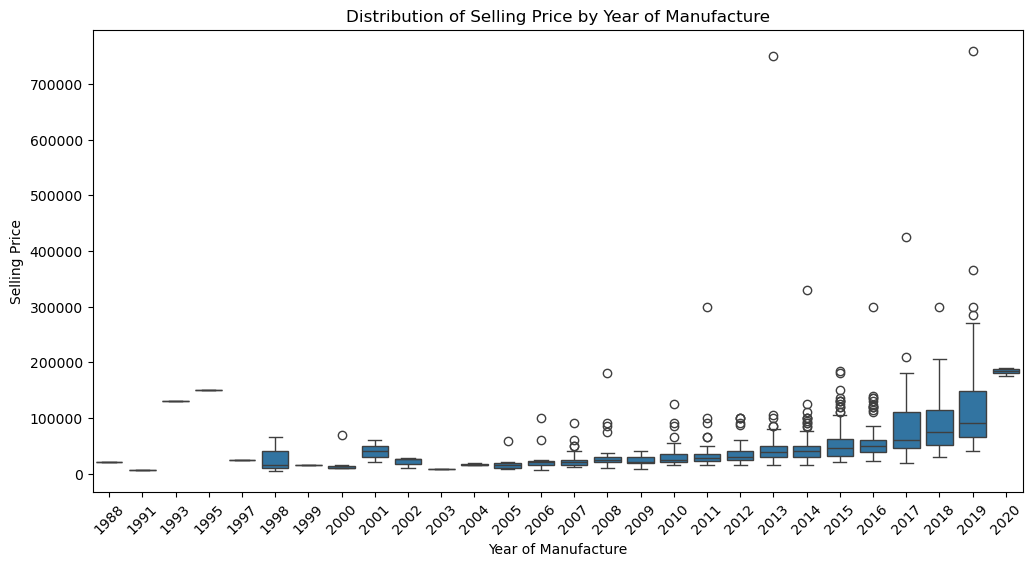

In [33]:
# Box plot to visualize selling price distribution by year
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_filtered, x="year", y="selling_price")
plt.xlabel("Year of Manufacture")
plt.ylabel("Selling Price")
plt.title("Distribution of Selling Price by Year of Manufacture")
plt.xticks(rotation=45)
plt.show()


#### What is the average depreciation in selling price based on the bike's age (current year - manufacturing year)

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1061 entries, 0 to 1060
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   name               1061 non-null   object 
 1   selling_price      1061 non-null   int64  
 2   year               1061 non-null   int64  
 3   seller_type        1061 non-null   object 
 4   owner              1061 non-null   object 
 5   km_driven          1061 non-null   int64  
 6   ex_showroom_price  626 non-null    float64
dtypes: float64(1), int64(3), object(3)
memory usage: 58.2+ KB


In [36]:
curr_year= 2025
df["bike_age"] = 2025 - df["year"]

avg_depreciation = df.groupby("bike_age")["selling_price"].mean().diff().mean()

avg_depreciation

-6049.382716049383

####  Which bike names are priced significantly above the average price for their manufacturing year

In [38]:
df.head(1)

,name,selling_price,year,seller_type,owner,km_driven,ex_showroom_price,bike_age
0,Royal Enfield Classic 350,175000,2019,Individual,1st owner,350,NaN,6


In [39]:
# Calculate average selling price per manufacturing year
yearly_avg_price = df.groupby("year")["selling_price"].mean()

# Find bikes priced above the average for their manufacturing year
high_priced_bikes = df[df["selling_price"] > df["year"].map(yearly_avg_price)]

# Get only the bike names
high_priced_bike_names = high_priced_bikes["name"].reset_index(drop=True)

high_priced_bike_names


0                 Royal Enfield Classic 350
1       Royal Enfield Classic Gunmetal Grey
2         Yamaha Fazer FI V 2.0 [2016-2018]
3      Royal Enfield Bullet 350 [2007-2011]
4                             Yamaha YZF R3
                       ...                 
329                    Bajaj Pulsar  NS 200
330                      TVS Apache RTR 160
331                      Bajaj Pulsar 220 F
332                     Bajaj Pulsar NS 200
333                  Bajaj Avenger 220 dtsi
Name: name, Length: 334, dtype: object

####  Develop a correlation matrix for numeric columns and visualize it using a heatmap

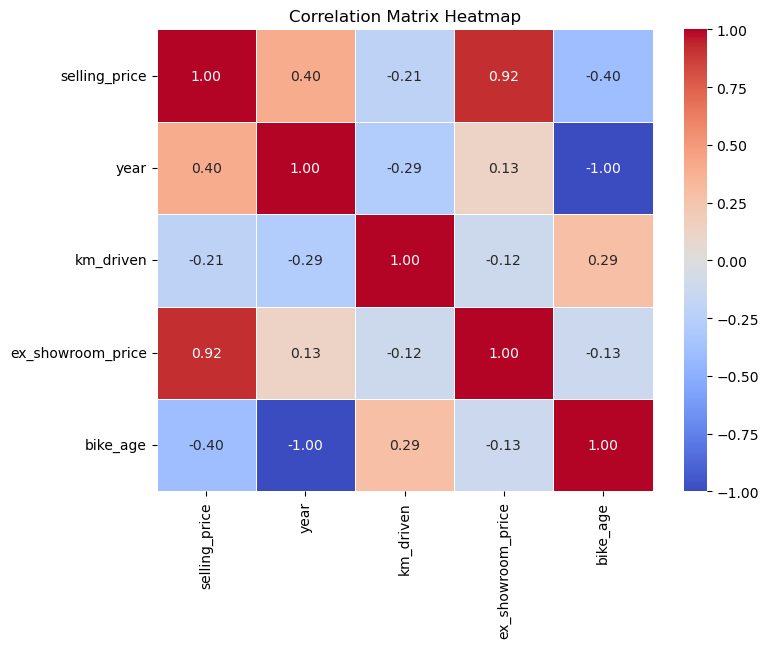

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numeric columns
numeric_df = df.select_dtypes(include=["number"])

# Compute the correlation matrix
correlation_matrix = numeric_df.corr()

# Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix Heatmap")
plt.show()


### EDA - 2
#### Title: Car Sale Dataset

In [43]:
car_df = pd.read_csv(r"../Dataset/Car sale.csv")
car_df.columns

Index(['Car_id', 'Date', 'Customer Name', 'Gender', 'Annual Income',
       'Dealer_Name', 'Company', 'Model', 'Engine', 'Transmission', 'Color',
       'Price ($)', 'Dealer_No ', 'Body Style', 'Phone', 'Dealer_Region'],
      dtype='object')

#### What is the average selling price of cars for each dealer, and how does it compare across different dealers

In [45]:
car_df.groupby('Dealer_Name')['Price ($)'].mean().sort_values(ascending=False)

Dealer_Name
U-Haul CO                                          28769.919006
Classic Chevy                                      28602.014446
Rabun Used Car Sales                               28527.536177
Iceberg Rentals                                    28522.958533
Enterprise Rent A Car                              28312.580800
Scrivener Performance Engineering                  28297.371589
Gartner Buick Hyundai Saab                         28247.621019
Saab-Belle Dodge                                   28190.139888
Capitol KIA                                        28189.703822
Race Car Help                                      28163.372706
Chrysler of Tri-Cities                             28123.091054
Star Enterprises Inc                               28113.055244
Suburban Ford                                      28112.206758
C & M Motors Inc                                   28111.755200
Tri-State Mack Inc                                 28095.562050
Pars Auto Sales             

####  Which car brand (Company) has the highest variation in prices, and what does this tell us about the pricing trends?

In [47]:
# Calculate the standard deviation of prices for each car brand (Company) to measure variation
brand_price_variation = car_df.groupby("Company")["Price ($)"].std().sort_values(ascending=False)

# Display the brand with the highest price variation
brand_price_variation


Company
Lincoln       19658.050211
Saab          19653.740089
Cadillac      19517.120220
Plymouth      19065.997338
Lexus         17852.923492
Buick         17142.232626
Mercury       16445.172195
Nissan        16214.264017
Saturn        15990.223671
Ford          15849.090227
Mercedes-B    15722.807459
Oldsmobile    15711.345857
Toyota        15367.131714
BMW           15065.578723
Pontiac       14348.963592
Infiniti      13696.332844
Chevrolet     13311.063223
Volvo         12933.790185
Subaru        12920.771620
Audi          12904.243867
Volkswagen    12527.124011
Mitsubishi    11671.343035
Chrysler      11583.286811
Dodge         11187.592085
Honda         11148.629062
Jaguar        10222.531533
Jeep           9459.834418
Acura          8183.046414
Porsche        5261.839206
Hyundai        3485.982649
Name: Price ($), dtype: float64

##### Car Brand with the Highest Price Variation:-

The brand with the highest price variation is Lincoln, with a standard deviation of $19,658 in prices, followed closely by Saab ($19,653) and Cadillac ($19,517).

##### What This Means:

High price variation suggests that these brands have a wide range of models, from budget-friendly to luxury.
Brands like Lincoln, Cadillac, and Saab offer both standard and premium models, leading to large differences in prices.
In contrast, brands with low variation (like Hyundai, Acura, and Porsche) may have more consistent pricing across their models.

#### What is the distribution of car prices for each transmission type, and how do the interquartile ranges compare

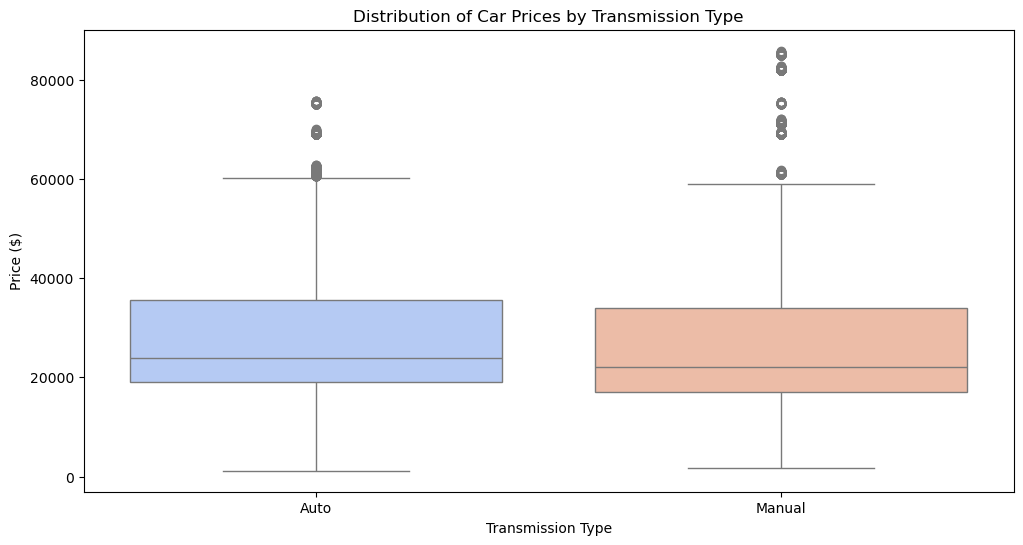

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set figure size
plt.figure(figsize=(12, 6))

# Create a boxplot to show price distribution for each transmission type
sns.boxplot(x="Transmission", y="Price ($)", data=car_df, palette="coolwarm")

# Add title and labels
plt.title("Distribution of Car Prices by Transmission Type")
plt.xlabel("Transmission Type")
plt.ylabel("Price ($)")

# Show the plot
plt.show()


#### What is the distribution of car prices across different regions

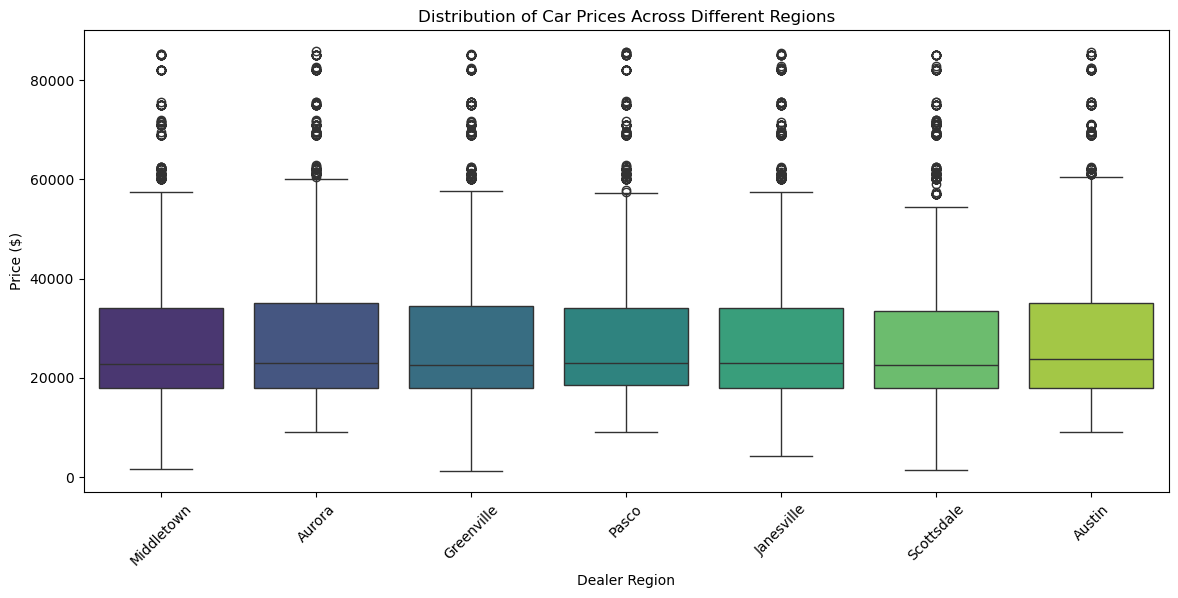

In [52]:
# Set figure size
plt.figure(figsize=(14, 6))

# Create a boxplot to show price distribution across different regions
sns.boxplot(x="Dealer_Region", y="Price ($)", data=car_df, palette="viridis")

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Add title and labels
plt.title("Distribution of Car Prices Across Different Regions")
plt.xlabel("Dealer Region")
plt.ylabel("Price ($)")

# Show the plot
plt.show()


#### What is the distribution of cars based on body styles

In [54]:
car_df.head(1)

,Car_id,Date,Customer Name,Gender,Annual Income,Dealer_Name,Company,Model,Engine,Transmission,Color,Price ($),Dealer_No,Body Style,Phone,Dealer_Region
0,C_CND_000001,1/2/2022,Geraldine,Male,13500,Buddy Storbeck's Diesel Service Inc,Ford,Expedition,DoubleÂ Overhead Camshaft,Auto,Black,26000,06457-3834,SUV,8264678,Middletown


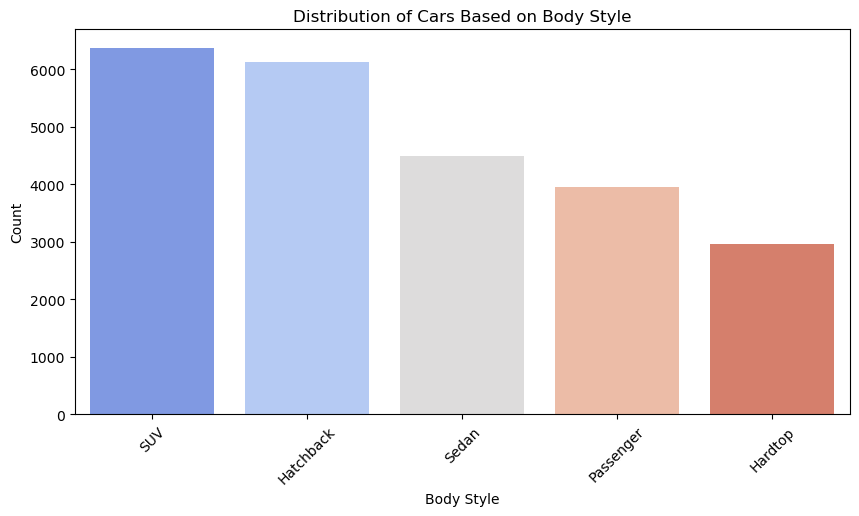

Body Style
SUV          6374
Hatchback    6128
Sedan        4488
Passenger    3945
Hardtop      2971
Name: count, dtype: int64

In [55]:
import seaborn as sns
import matplotlib.pyplot as plt

# Count the number of cars in each body style category
plt.figure(figsize=(10, 5))
sns.countplot(x="Body Style", data=car_df, palette="coolwarm", order=car_df["Body Style"].value_counts().index)
plt.xticks(rotation=45)
plt.xlabel("Body Style")
plt.ylabel("Count")
plt.title("Distribution of Cars Based on Body Style")
plt.show()

# Display the numerical distribution
car_body_style_counts = car_df["Body Style"].value_counts()
car_body_style_counts


####  How does the average selling price of cars vary by customer gender and annual income

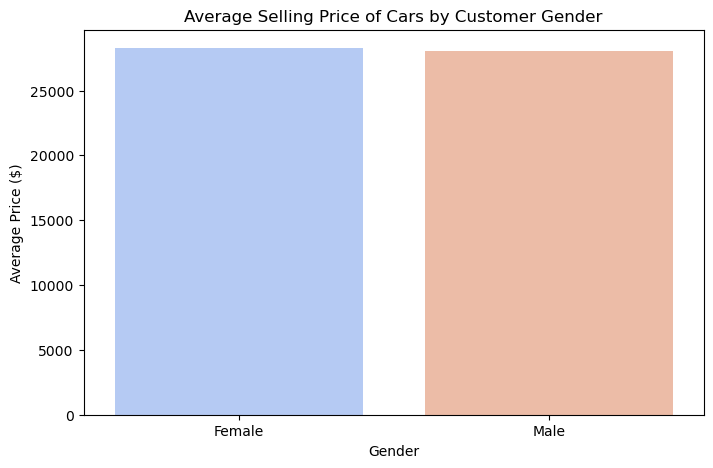

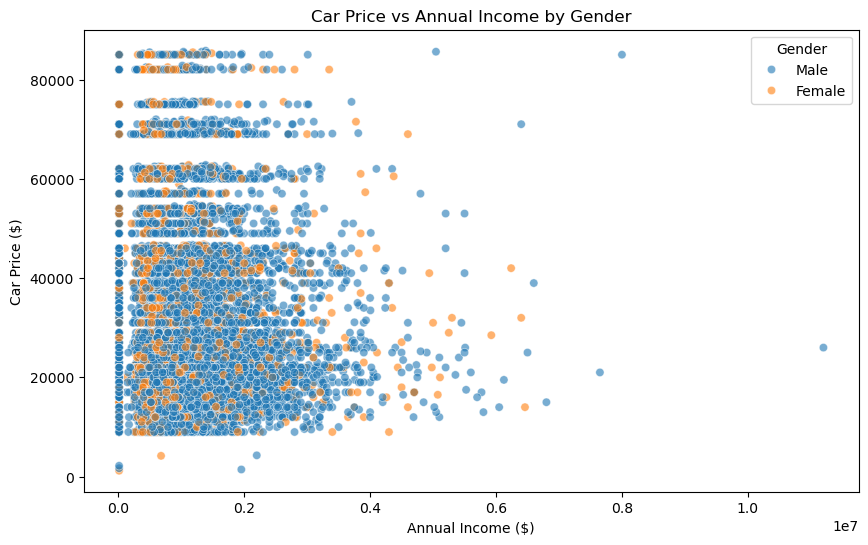

Gender
Female    28277.265270
Male      28039.429407
Name: Price ($), dtype: float64

In [57]:
# Calculate the average selling price by gender
avg_price_by_gender = car_df.groupby("Gender")["Price ($)"].mean()

# Plot the average selling price by gender
plt.figure(figsize=(8, 5))
sns.barplot(x=avg_price_by_gender.index, y=avg_price_by_gender.values, palette="coolwarm")
plt.xlabel("Gender")
plt.ylabel("Average Price ($)")
plt.title("Average Selling Price of Cars by Customer Gender")
plt.show()

# Scatter plot of annual income vs car price with gender hue
plt.figure(figsize=(10, 6))
sns.scatterplot(x="Annual Income", y="Price ($)", hue="Gender", data=car_df, alpha=0.6)
plt.xlabel("Annual Income ($)")
plt.ylabel("Car Price ($)")
plt.title("Car Price vs Annual Income by Gender")
plt.legend(title="Gender")
plt.show()

# Display the numerical average prices by gender
avg_price_by_gender


#### What is the distribution of car prices by region, and how does the number of cars sold vary by region

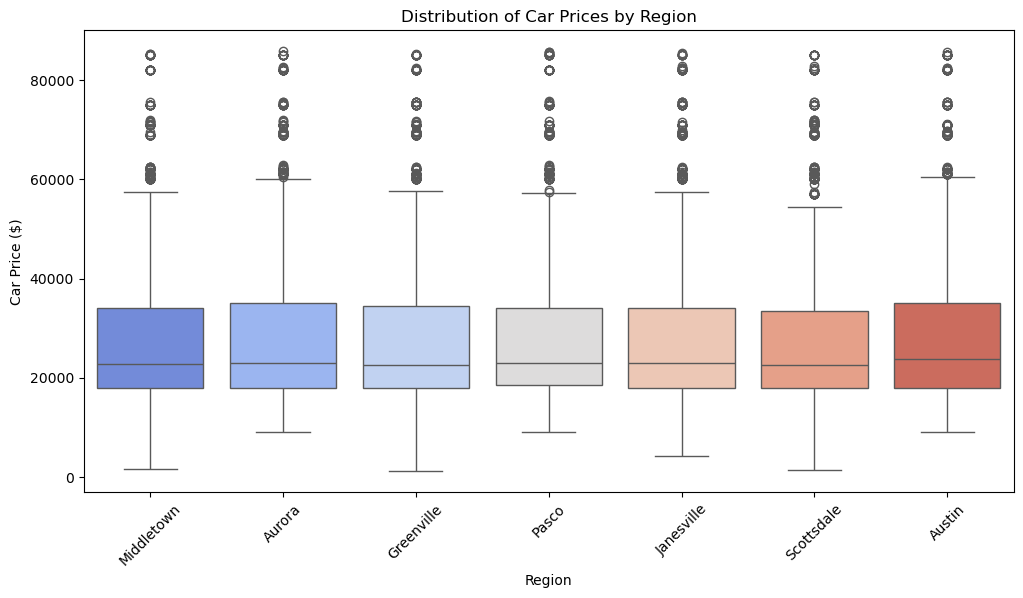

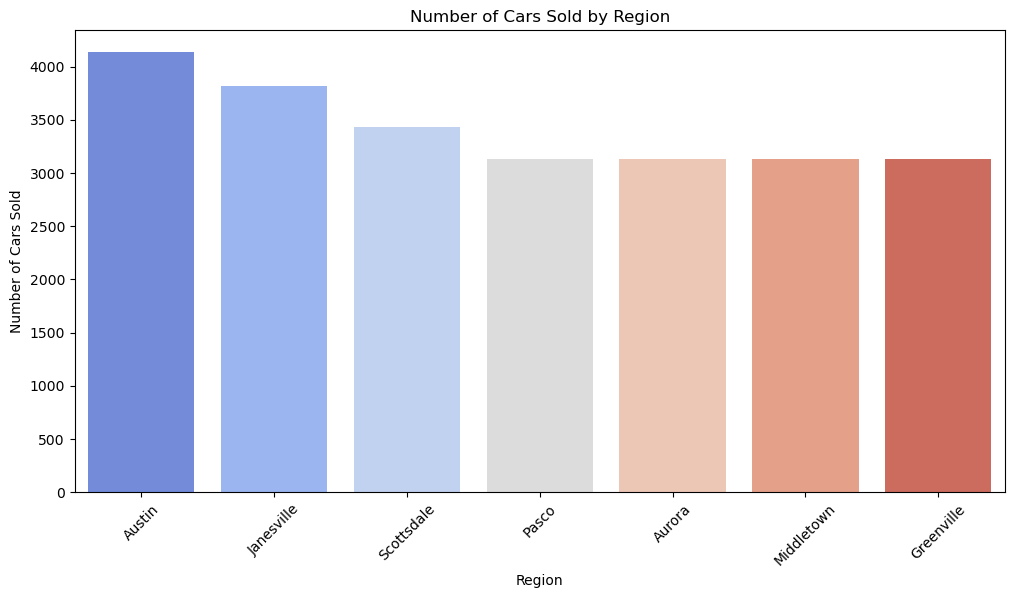

Dealer_Region
Austin        4135
Janesville    3821
Scottsdale    3433
Pasco         3131
Aurora        3130
Middletown    3128
Greenville    3128
Name: count, dtype: int64

In [59]:
# Set figure size
plt.figure(figsize=(12, 6))

# Box plot of car prices by region
sns.boxplot(x="Dealer_Region", y="Price ($)", data=car_df, palette="coolwarm")
plt.xticks(rotation=45)
plt.xlabel("Region")
plt.ylabel("Car Price ($)")
plt.title("Distribution of Car Prices by Region")
plt.show()

# Count the number of cars sold per region
plt.figure(figsize=(12, 6))
sns.countplot(x="Dealer_Region", data=car_df, palette="coolwarm", order=car_df["Dealer_Region"].value_counts().index)
plt.xticks(rotation=45)
plt.xlabel("Region")
plt.ylabel("Number of Cars Sold")
plt.title("Number of Cars Sold by Region")
plt.show()

# Display the numerical distribution of cars sold per region
car_sales_by_region = car_df["Dealer_Region"].value_counts()
car_sales_by_region


#### How does the average car price differ between cars with different engine sizes

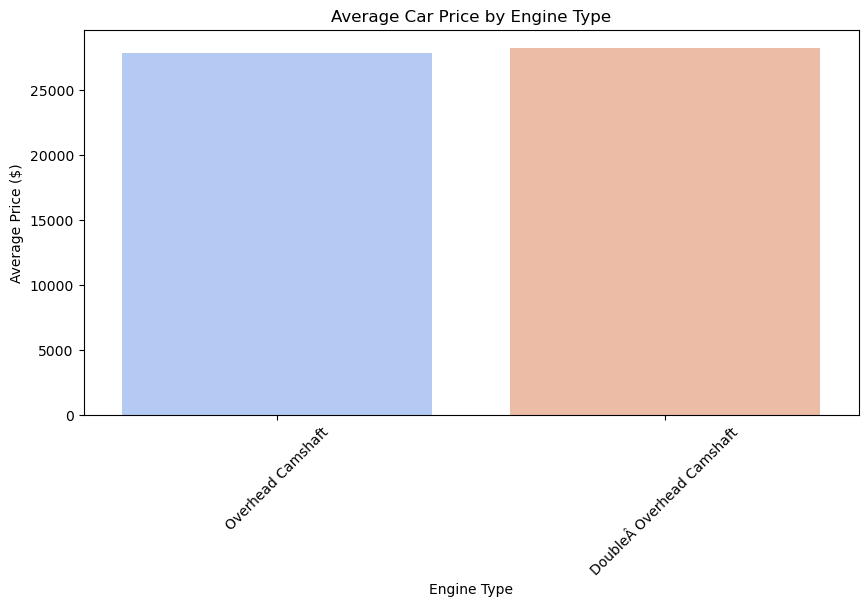

Engine
Overhead Camshaft            27914.710631
DoubleÂ Overhead Camshaft    28248.525972
Name: Price ($), dtype: float64

In [61]:
# Calculate the average car price for each engine type
avg_price_by_engine = car_df.groupby("Engine")["Price ($)"].mean().sort_values()

# Plot the average car price by engine type
plt.figure(figsize=(10, 5))
sns.barplot(x=avg_price_by_engine.index, y=avg_price_by_engine.values, palette="coolwarm")
plt.xticks(rotation=45)
plt.xlabel("Engine Type")
plt.ylabel("Average Price ($)")
plt.title("Average Car Price by Engine Type")
plt.show()

# Display the numerical results
avg_price_by_engine


####  How do car prices vary based on the customer’s annual income bracket

In [63]:
car_df.head(1)

,Car_id,Date,Customer Name,Gender,Annual Income,Dealer_Name,Company,Model,Engine,Transmission,Color,Price ($),Dealer_No,Body Style,Phone,Dealer_Region
0,C_CND_000001,1/2/2022,Geraldine,Male,13500,Buddy Storbeck's Diesel Service Inc,Ford,Expedition,DoubleÂ Overhead Camshaft,Auto,Black,26000,06457-3834,SUV,8264678,Middletown


In [64]:
car_df['Annual Income'].median()

735000.0

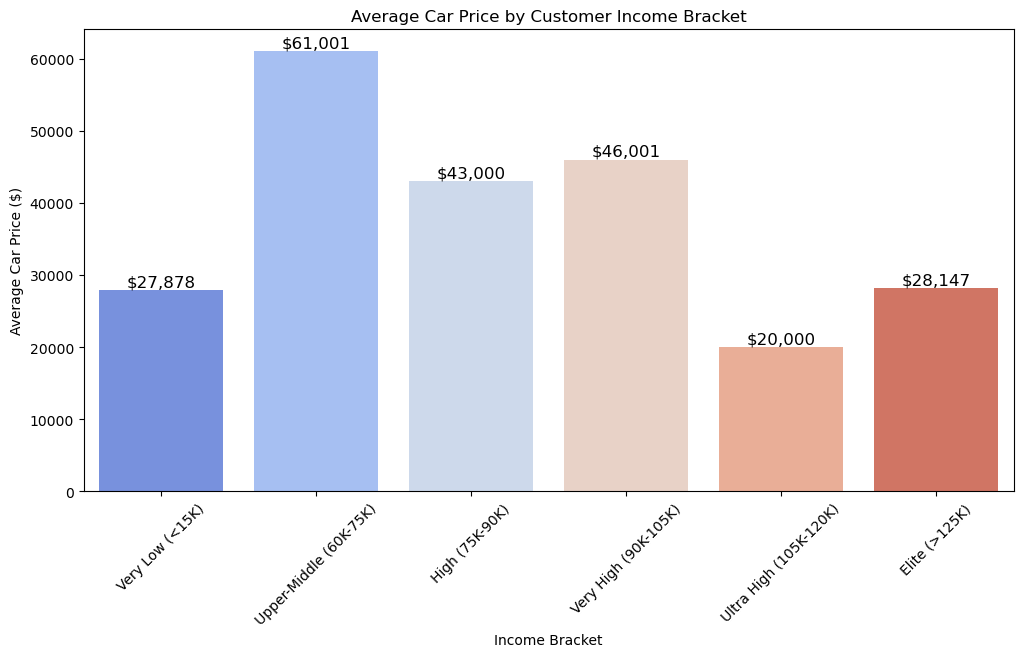

Income Bracket
Very Low (<15K)           27878.018582
Upper-Middle (60K-75K)    61001.000000
High (75K-90K)            43000.000000
Very High (90K-105K)      46001.000000
Ultra High (105K-120K)    20000.000000
Elite (>125K)             28147.240337
Name: Price ($), dtype: float64

In [65]:
# Re-load the dataset
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt



# Define more diverse income brackets
income_bins = [0, 15000,  80000, 95000, 110000, 125000, car_df["Annual Income"].max()]
income_labels = [
    "Very Low (<15K)", "Upper-Middle (60K-75K)", "High (75K-90K)",
    "Very High (90K-105K)", "Ultra High (105K-120K)", "Elite (>125K)"
]

# Create a new column for income brackets
car_df["Income Bracket"] = pd.cut(car_df["Annual Income"], bins=income_bins, labels=income_labels, include_lowest=True)

# Calculate the average car price for each income bracket
avg_price_by_income = car_df.groupby("Income Bracket")["Price ($)"].mean().reindex(income_labels)

# Plot the results with value labels
plt.figure(figsize=(12, 6))
ax = sns.barplot(x=avg_price_by_income.index, y=avg_price_by_income.values, palette="coolwarm")
plt.xticks(rotation=45)
plt.xlabel("Income Bracket")
plt.ylabel("Average Car Price ($)")
plt.title("Average Car Price by Customer Income Bracket")

# Add value labels
for i, v in enumerate(avg_price_by_income):
    ax.text(i, v + 500, f"${v:,.0f}", ha="center", fontsize=12)

plt.show()

# Display numerical results
avg_price_by_income


#### What are the top 5 car models with the highest number of sales, and how does their price distribution look

In [67]:
car_df.columns

Index(['Car_id', 'Date', 'Customer Name', 'Gender', 'Annual Income',
       'Dealer_Name', 'Company', 'Model', 'Engine', 'Transmission', 'Color',
       'Price ($)', 'Dealer_No ', 'Body Style', 'Phone', 'Dealer_Region',
       'Income Bracket'],
      dtype='object')

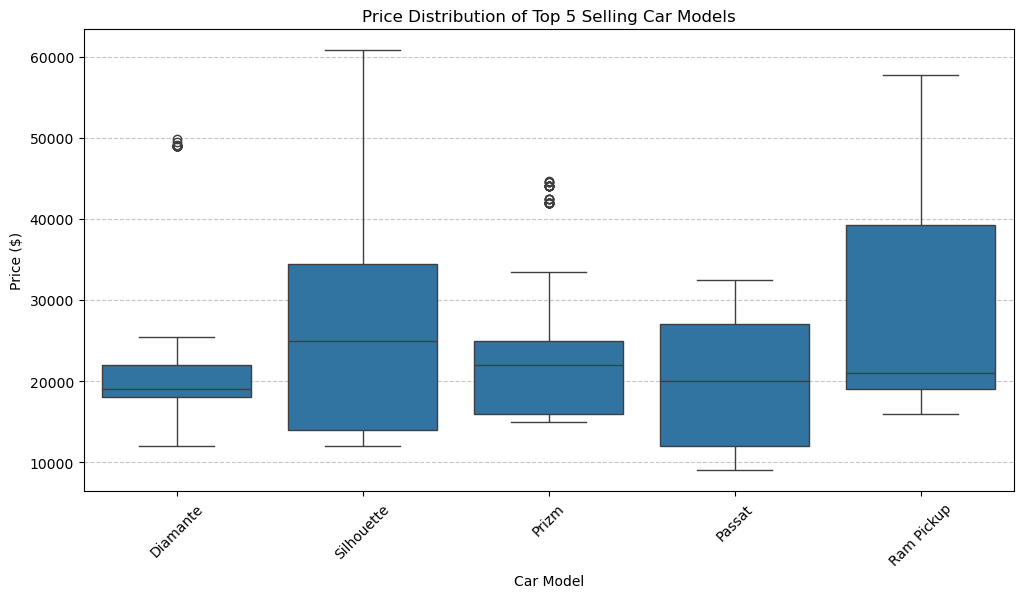

Model
Diamante      418
Silhouette    411
Prizm         411
Passat        391
Ram Pickup    383
Name: count, dtype: int64

In [68]:
# Find the top 5 car models with the highest number of sales
# Convert top models Series to DataFrame with 'Count' as column name
top_models = car_df['Model'].value_counts().head(5)
# top_models.columns = ['Model', 'Count'] #making column name


#visulization
import matplotlib.pyplot as plt
import seaborn as sns

# Filter data for the top 5 models
top_models_data = car_df[car_df['Model'].isin(top_models.index)]

# Plot price distribution
plt.figure(figsize=(12, 6))
sns.boxplot(x='Model', y='Price ($)', data=top_models_data, order=top_models.index)
plt.title('Price Distribution of Top 5 Selling Car Models')
plt.xlabel('Car Model')
plt.ylabel('Price ($)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

top_models

#### How does car price vary with engine size across different car colors, and which colors have the highest price variation

In [70]:
car_df.head(1)

,Car_id,Date,Customer Name,Gender,Annual Income,Dealer_Name,Company,Model,Engine,Transmission,Color,Price ($),Dealer_No,Body Style,Phone,Dealer_Region,Income Bracket
0,C_CND_000001,1/2/2022,Geraldine,Male,13500,Buddy Storbeck's Diesel Service Inc,Ford,Expedition,DoubleÂ Overhead Camshaft,Auto,Black,26000,06457-3834,SUV,8264678,Middletown,Very Low (<15K)


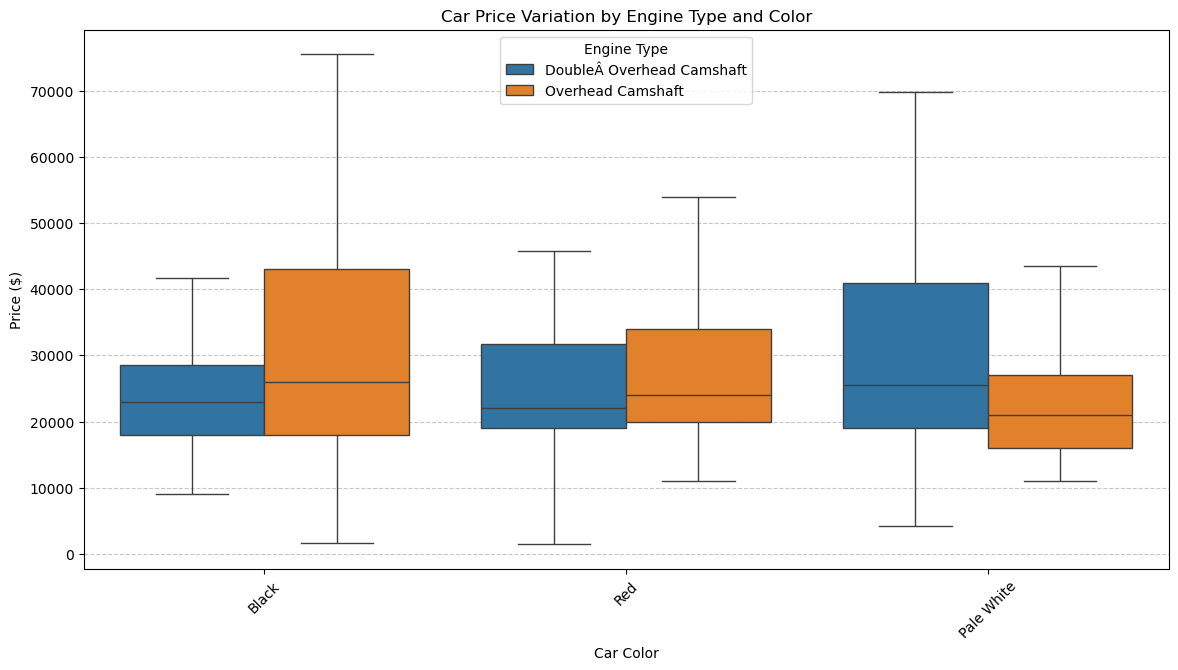

In [71]:
# Standardizing Engine types by removing special characters and spaces
car_df['Engine'] = car_df['Engine'].str.replace(r'\s+', ' ', regex=True).str.strip()

# Calculate price variation (standard deviation) for each car color
color_price_variation = car_df.groupby('Color')['Price ($)'].std().reset_index()
color_price_variation.columns = ['Color', 'Price Std Dev']

# Sort colors by highest price variation
color_price_variation = color_price_variation.sort_values(by='Price Std Dev', ascending=False)

# Display the top 5 colors with the highest price variation
color_price_variation.head()

# Create a box plot to visualize car price variation by engine type and color
plt.figure(figsize=(14, 7))
sns.boxplot(x='Color', y='Price ($)', hue='Engine', data=car_df, showfliers=False)
plt.title('Car Price Variation by Engine Type and Color')
plt.xlabel('Car Color')
plt.ylabel('Price ($)')
plt.xticks(rotation=45)
plt.legend(title='Engine Type')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()



####  Is there any seasonal trend in car sales based on the date of sale

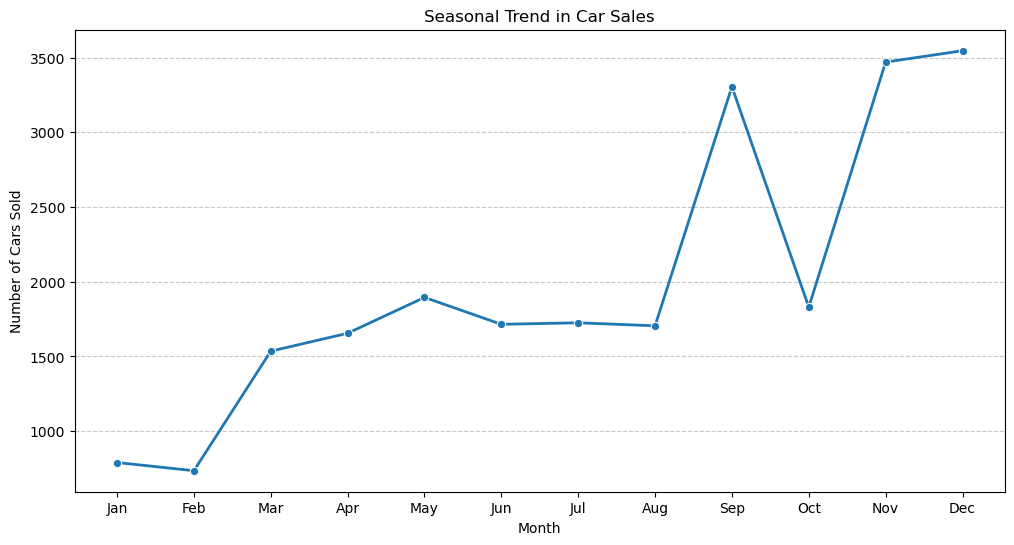

In [73]:
# Convert 'Date' column to datetime format
car_df['Date'] = pd.to_datetime(car_df['Date'])

# Extract month from the date
car_df['Month'] = car_df['Date'].dt.month

# Count the number of sales per month
monthly_sales = car_df['Month'].value_counts().sort_index()

# Plot the seasonal trend in car sales
plt.figure(figsize=(12, 6))
sns.lineplot(x=monthly_sales.index, y=monthly_sales.values, marker='o', linewidth=2)
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.title('Seasonal Trend in Car Sales')
plt.xlabel('Month')
plt.ylabel('Number of Cars Sold')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


In [74]:
car_df.head(1)

,Car_id,Date,Customer Name,Gender,Annual Income,Dealer_Name,Company,Model,Engine,Transmission,Color,Price ($),Dealer_No,Body Style,Phone,Dealer_Region,Income Bracket,Month
0,C_CND_000001,2022-01-02,Geraldine,Male,13500,Buddy Storbeck's Diesel Service Inc,Ford,Expedition,DoubleÂ Overhead Camshaft,Auto,Black,26000,06457-3834,SUV,8264678,Middletown,Very Low (<15K),1


####  How does the car price distribution change when considering different combinations of body style and transmission type

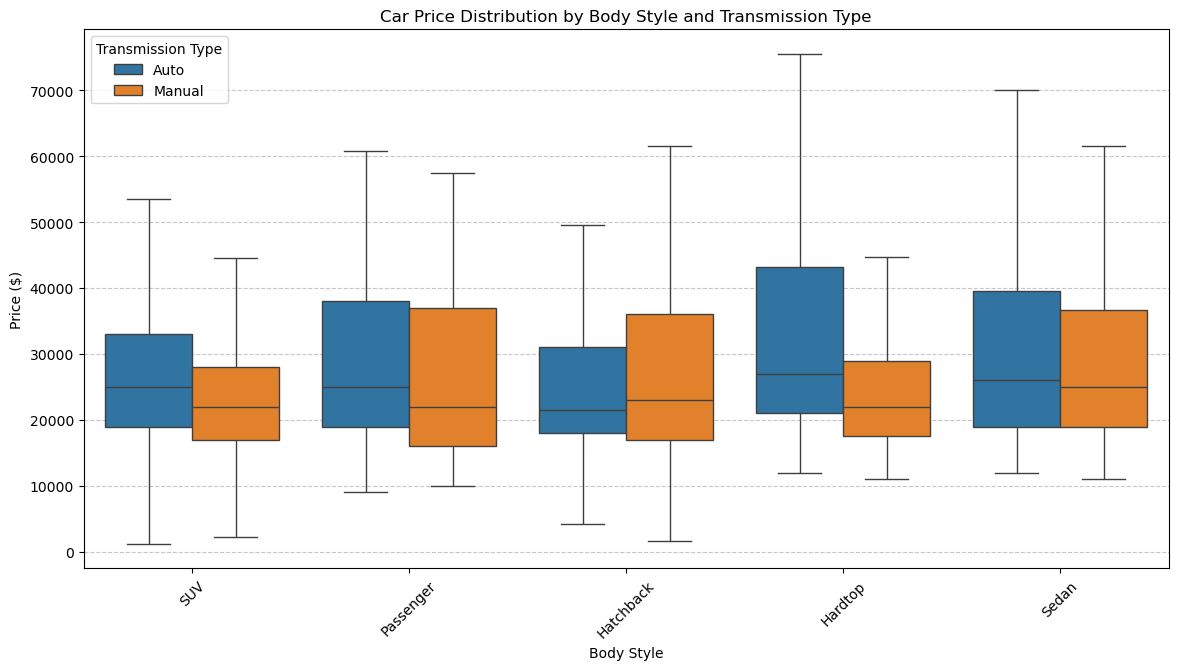

In [76]:
# Create a box plot to visualize price distribution by Body Style and Transmission Type
plt.figure(figsize=(14, 7))
sns.boxplot(x='Body Style', y='Price ($)', hue='Transmission', data=car_df, showfliers=False)
plt.title('Car Price Distribution by Body Style and Transmission Type')
plt.xlabel('Body Style')
plt.ylabel('Price ($)')
plt.xticks(rotation=45)
plt.legend(title='Transmission Type')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


####  What is the correlation between car price, engine size, and annual income of customers, and how do these features interact

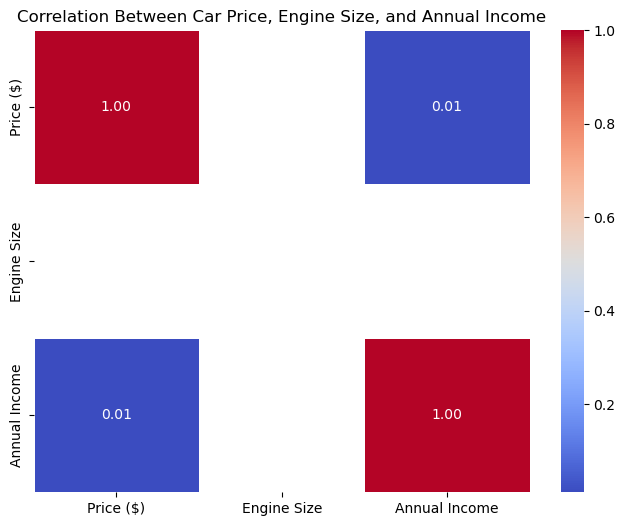

In [78]:


# Extract engine size if numerical values exist in 'Engine' column
car_df['Engine Size'] = car_df['Engine'].str.extract(r'(\d+\.?\d*)').astype(float)

# Select relevant columns for correlation analysis
correlation_data = car_df[['Price ($)', 'Engine Size', 'Annual Income']]

# Compute correlation matrix
correlation_matrix = correlation_data.corr()

# Plot correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Between Car Price, Engine Size, and Annual Income')
plt.show()


####  How does the average car price vary across different car models and engine types

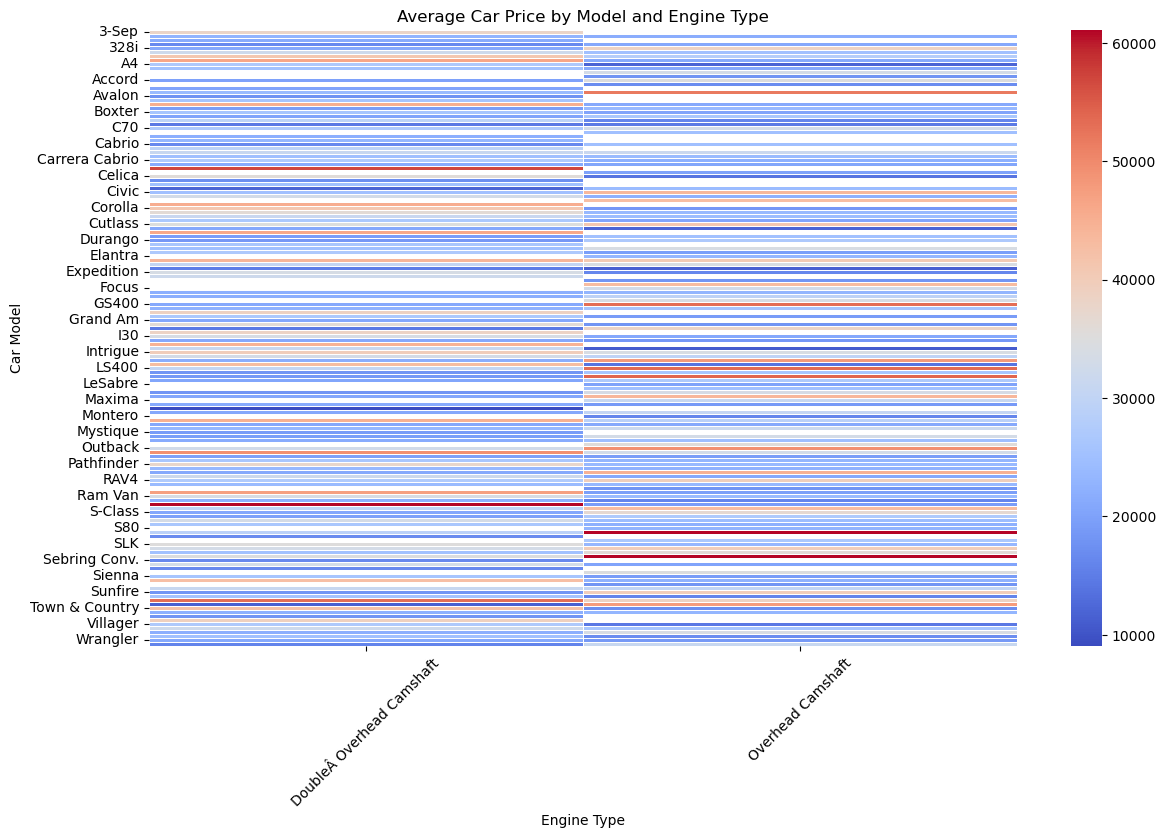

In [80]:
# Group data by Model and Engine Type, then calculate average price
avg_price_by_model_engine = car_df.groupby(['Model', 'Engine'])['Price ($)'].mean().reset_index()

# Pivot the data for better visualization in a heatmap
avg_price_pivot = avg_price_by_model_engine.pivot(index='Model', columns='Engine', values='Price ($)')

# Plot heatmap to show variation in average car price
plt.figure(figsize=(14, 8))
sns.heatmap(avg_price_pivot, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Average Car Price by Model and Engine Type')
plt.xlabel('Engine Type')
plt.ylabel('Car Model')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()


### EDA 3
#### 

In [82]:
amazon_df = pd.read_csv(r"../Dataset/amazon.csv")
amazon_df.head(1)

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...


In [83]:
amazon_df.rating.dtype

dtype('O')

In [84]:
amazon_df = amazon_df[amazon_df['rating'] != '|']


#### What is the average rating for each product category

In [86]:
# Convert rating to numeric, forcing errors to NaN for safety
amazon_df["rating"] = pd.to_numeric(amazon_df["rating"], errors="coerce")

# Compute average rating per category
average_ratings = amazon_df.groupby("category")["rating"].mean().reset_index()

# Sort by highest rating
average_ratings = average_ratings.sort_values(by="rating", ascending=False)

# Display results
average_ratings


,category,rating
57,Computers&Accessories|Tablets,4.6
48,Computers&Accessories|NetworkingDevices|Networ...,4.5
62,Electronics|Cameras&Photography|Accessories|Film,4.5
81,Electronics|HomeAudio|MediaStreamingDevices|St...,4.5
196,OfficeProducts|OfficeElectronics|Calculators|B...,4.5
...,...,...
3,Computers&Accessories|Accessories&Peripherals|...,3.6
88,"Electronics|HomeTheater,TV&Video|Accessories|3...",3.5
2,Computers&Accessories|Accessories&Peripherals|...,3.5
14,Computers&Accessories|Accessories&Peripherals|...,3.4


#### What are the top rating_count of products by category

In [88]:
amazon_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1464 entries, 0 to 1464
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   product_id           1464 non-null   object 
 1   product_name         1464 non-null   object 
 2   category             1464 non-null   object 
 3   discounted_price     1464 non-null   object 
 4   actual_price         1464 non-null   object 
 5   discount_percentage  1464 non-null   object 
 6   rating               1464 non-null   float64
 7   rating_count         1462 non-null   object 
 8   about_product        1464 non-null   object 
 9   user_id              1464 non-null   object 
 10  user_name            1464 non-null   object 
 11  review_id            1464 non-null   object 
 12  review_title         1464 non-null   object 
 13  review_content       1464 non-null   object 
 14  img_link             1464 non-null   object 
 15  product_link         1464 non-null   object

In [89]:
# Convert 'rating_count' to numeric (remove commas and convert to int)
amazon_df["rating_count"] = amazon_df["rating_count"].astype(str).str.replace(",", "").astype(float)

# Identify the top-rated product in each category based on the highest rating count
top_rated_products = amazon_df.loc[amazon_df.groupby("category")["rating_count"].idxmax(), ["category", "product_name", "rating", "rating_count"]]

# Sort by rating_count in descending order
top_rated_products = top_rated_products.sort_values(by="rating_count", ascending=False)

# Display results
top_rated_products


,category,product_name,rating,rating_count
12,"Electronics|HomeTheater,TV&Video|Accessories|C...",AmazonBasics Flexible Premium HDMI Cable (Blac...,4.4,426973.0
352,"Electronics|Headphones,Earbuds&Accessories|Hea...",boAt Bassheads 100 in Ear Wired Earphones with...,4.1,363713.0
370,Electronics|Mobiles&Accessories|Smartphones&Ba...,"Redmi 9 Activ (Carbon Black, 4GB RAM, 64GB Sto...",4.1,313836.0
1028,Home&Kitchen|Kitchen&Dining|KitchenTools|Manua...,Pigeon Polypropylene Mini Handy and Compact Ch...,4.1,270563.0
588,Computers&Accessories|ExternalDevices&DataStor...,SanDisk Cruzer Blade 32GB USB Flash Drive,4.3,253105.0
...,...,...,...,...
863,Computers&Accessories|Components|InternalHardD...,"Lapster Caddy for ssd and HDD, Optical Bay 2nd...",4.2,362.0
1014,Computers&Accessories|Laptops|TraditionalLaptops,"Lenovo IdeaPad 3 11th Gen Intel Core i3 15.6"" ...",4.0,323.0
557,Electronics|Mobiles&Accessories|MobileAccessor...,LAPSTER 12pcs Spiral Cable Protectors for Char...,4.4,305.0
269,Electronics|HomeAudio|Speakers|TowerSpeakers,"KRISONS Thunder Speaker, Multimedia Home Theat...",3.8,282.0


#### What is the distribution of discounted prices vs. actual prices

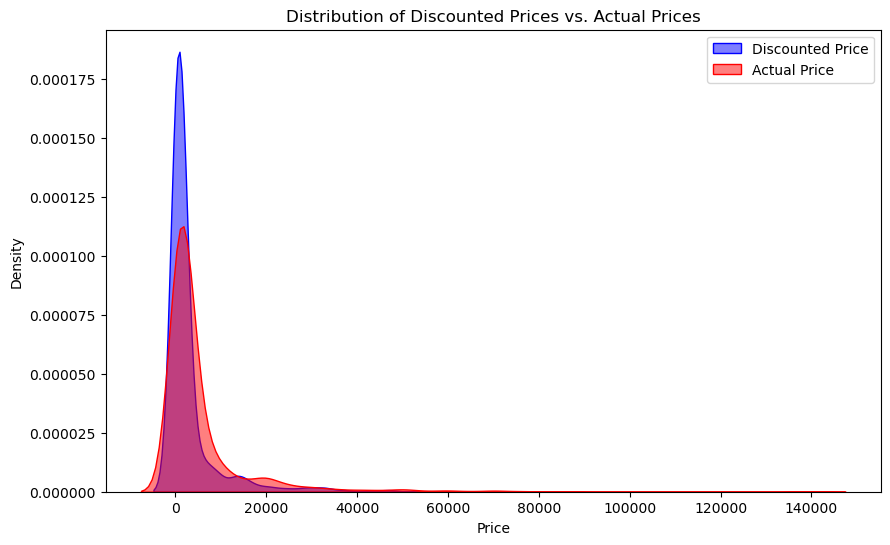

In [91]:

# Convert price columns to numeric after removing non-numeric characters (like currency symbols)
amazon_df["discounted_price"] = pd.to_numeric(amazon_df["discounted_price"].astype(str).str.replace(r"[^\d.]", "", regex=True), errors="coerce")
amazon_df["actual_price"] = pd.to_numeric(amazon_df["actual_price"].astype(str).str.replace(r"[^\d.]", "", regex=True), errors="coerce")

# Plot distribution of discounted vs. actual prices
plt.figure(figsize=(10, 6))
sns.kdeplot(amazon_df["discounted_price"].dropna(), label="Discounted Price", fill=True, color="blue", alpha=0.5)
sns.kdeplot(amazon_df["actual_price"].dropna(), label="Actual Price", fill=True, color="red", alpha=0.5)
plt.xlabel("Price")
plt.ylabel("Density")
plt.title("Distribution of Discounted Prices vs. Actual Prices")
plt.legend()
plt.show()


#### How does the average discount percentage vary across categories

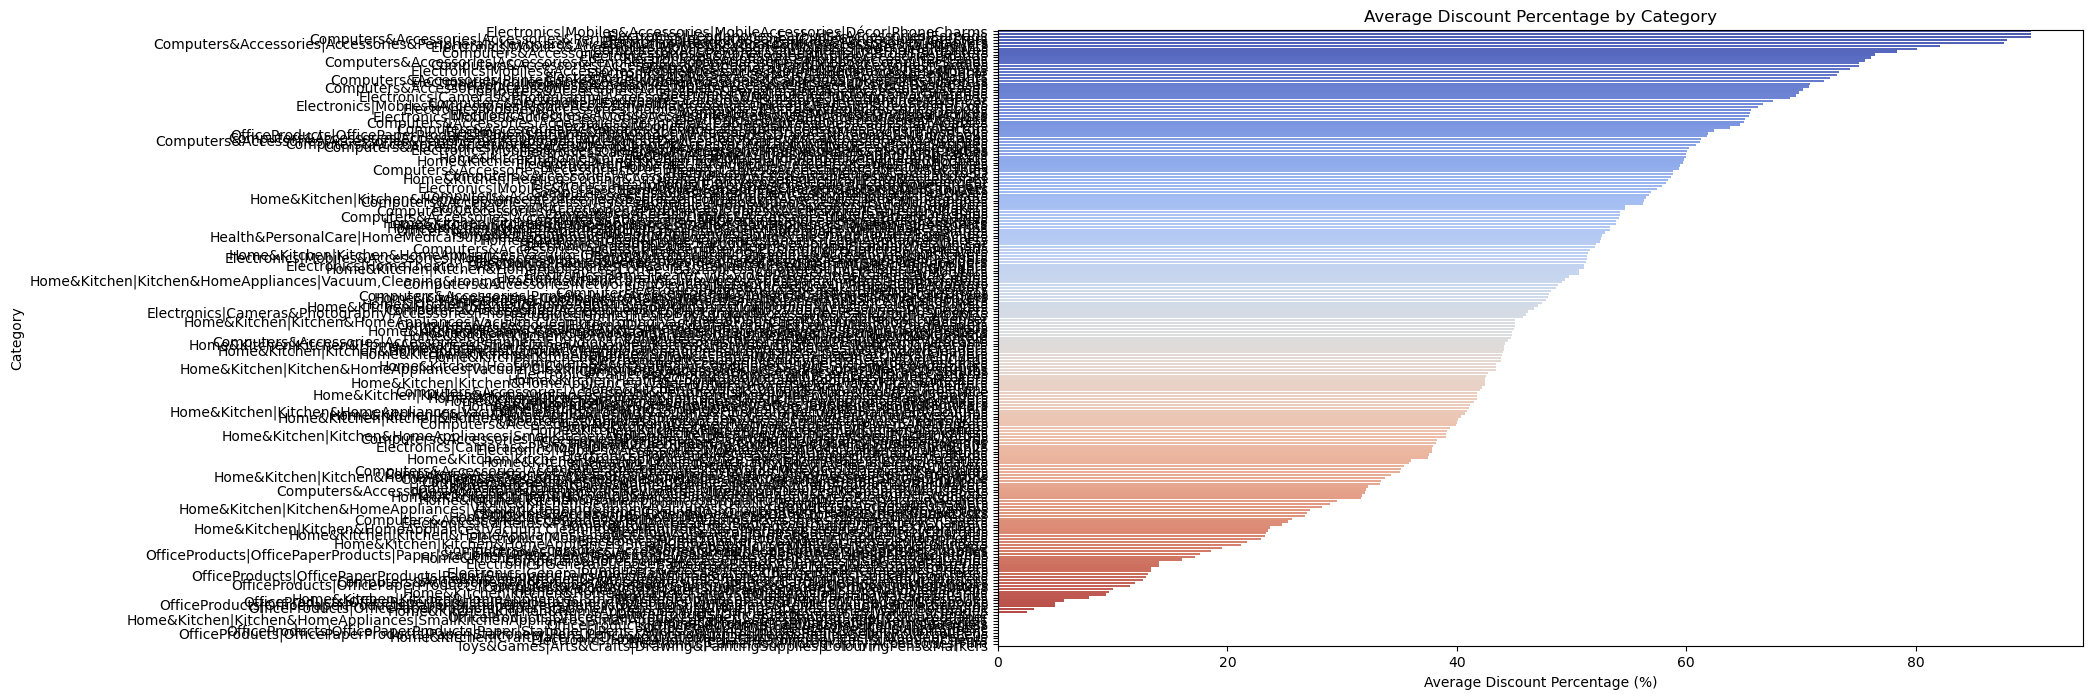

In [93]:
# Calculate discount percentage
amazon_df["discount_percentage"] = ((amazon_df["actual_price"] - amazon_df["discounted_price"]) / amazon_df["actual_price"]) * 100

# Compute average discount per category
avg_discount_by_category = amazon_df.groupby("category")["discount_percentage"].mean().reset_index()

# Sort categories by highest discount
avg_discount_by_category = avg_discount_by_category.sort_values(by="discount_percentage", ascending=False)

# Adjust figure size and rotate category labels for better readability
plt.figure(figsize=(14, 8))
sns.barplot(data=avg_discount_by_category, x="discount_percentage", y="category", palette="coolwarm")

plt.xlabel("Average Discount Percentage (%)")
plt.ylabel("Category")
plt.title("Average Discount Percentage by Category")
plt.xticks(rotation=0)  # Keep x-axis labels horizontal
plt.yticks(fontsize=10)  # Adjust font size for better readability

plt.show()



####  What are the most popular product names

In [95]:
# Sort products by highest rating count
most_popular_products = amazon_df.sort_values(by="rating_count", ascending=False)[["product_name", "rating", "rating_count"]]

# Display the top 10 most popular products
most_popular_products.head(10)


,product_name,rating,rating_count
12,AmazonBasics Flexible Premium HDMI Cable (Blac...,4.4,426973.0
65,"Amazon Basics High-Speed HDMI Cable, 6 Feet (2...",4.4,426973.0
47,"Amazon Basics High-Speed HDMI Cable, 6 Feet - ...",4.4,426973.0
684,AmazonBasics Flexible Premium HDMI Cable (Blac...,4.4,426972.0
400,boAt Bassheads 100 in Ear Wired Earphones with...,4.1,363713.0
352,boAt Bassheads 100 in Ear Wired Earphones with...,4.1,363713.0
584,boAt BassHeads 100 in-Ear Wired Headphones wit...,4.1,363711.0
370,"Redmi 9 Activ (Carbon Black, 4GB RAM, 64GB Sto...",4.1,313836.0
371,"Redmi 9A Sport (Coral Green, 2GB RAM, 32GB Sto...",4.1,313836.0
473,"Redmi 9A Sport (Carbon Black, 2GB RAM, 32GB St...",4.1,313832.0


#### What are the most popular product keywords

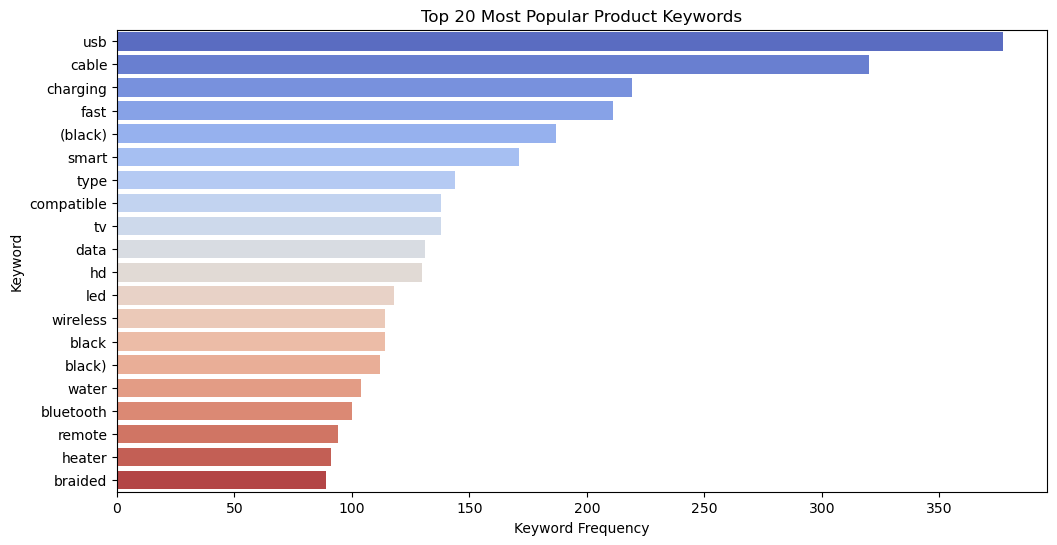

In [97]:
# Recalculate word frequencies
from collections import Counter

# Combine all product names into a single string
all_product_names = " ".join(amazon_df["product_name"].dropna())

# Split into words and count occurrences (excluding common stop words)
common_words = ["with", "for", "and", "the", "of", "to", "in", "on", "by", "a", "an"]
words = [word.lower() for word in all_product_names.split() if word.lower() not in common_words and len(word)>1]

# Count word frequency
word_counts = Counter(words)

# Get the 20 most common words
top_keywords = word_counts.most_common(20)
keywords, counts = zip(*top_keywords)

# Plot bar chart of top keywords
plt.figure(figsize=(12, 6))
sns.barplot(x=list(counts), y=list(keywords), palette="coolwarm")

plt.xlabel("Keyword Frequency")
plt.ylabel("Keyword")
plt.title("Top 20 Most Popular Product Keywords")
plt.show()


#### What are the most popular product reviews

In [99]:
amazon_df.columns

Index(['product_id', 'product_name', 'category', 'discounted_price',
       'actual_price', 'discount_percentage', 'rating', 'rating_count',
       'about_product', 'user_id', 'user_name', 'review_id', 'review_title',
       'review_content', 'img_link', 'product_link'],
      dtype='object')

In [100]:
# Top 10 most popular products

most_popular_product= amazon_df.sort_values(by='rating_count',ascending=False)[
    ["product_name", "review_title", "review_content", "rating", "rating_count"]
]
most_popular_product.head(10)

,product_name,review_title,review_content,rating,rating_count
12,AmazonBasics Flexible Premium HDMI Cable (Blac...,"It's quite good and value for money,Works well...",I am using it for 14 days now. The experience ...,4.4,426973.0
65,"Amazon Basics High-Speed HDMI Cable, 6 Feet (2...","It's quite good and value for money,Works well...",I am using it for 14 days now. The experience ...,4.4,426973.0
47,"Amazon Basics High-Speed HDMI Cable, 6 Feet - ...","It's quite good and value for money,Works well...",I am using it for 14 days now. The experience ...,4.4,426973.0
684,AmazonBasics Flexible Premium HDMI Cable (Blac...,"It's quite good and value for money,Works well...",I am using it for 14 days now. The experience ...,4.4,426972.0
400,boAt Bassheads 100 in Ear Wired Earphones with...,"Best value for money,HEAD PHONE POUCH NOT RECE...",The sound quality of this earphone are really ...,4.1,363713.0
352,boAt Bassheads 100 in Ear Wired Earphones with...,"Best value for money,HEAD PHONE POUCH NOT RECE...",The sound quality of this earphone are really ...,4.1,363713.0
584,boAt BassHeads 100 in-Ear Wired Headphones wit...,"Best value for money,HEAD PHONE POUCH NOT RECE...",The sound quality of this earphone are really ...,4.1,363711.0
370,"Redmi 9 Activ (Carbon Black, 4GB RAM, 64GB Sto...","Best phone for below normal use,Good mobile fo...",If you want a smart phone for just the use of ...,4.1,313836.0
371,"Redmi 9A Sport (Coral Green, 2GB RAM, 32GB Sto...","Best phone for below normal use,Good mobile fo...",If you want a smart phone for just the use of ...,4.1,313836.0
473,"Redmi 9A Sport (Carbon Black, 2GB RAM, 32GB St...","Best phone for below normal use,Good mobile fo...",If you want a smart phone for just the use of ...,4.1,313832.0


#### What is the correlation between discounted_price and rating

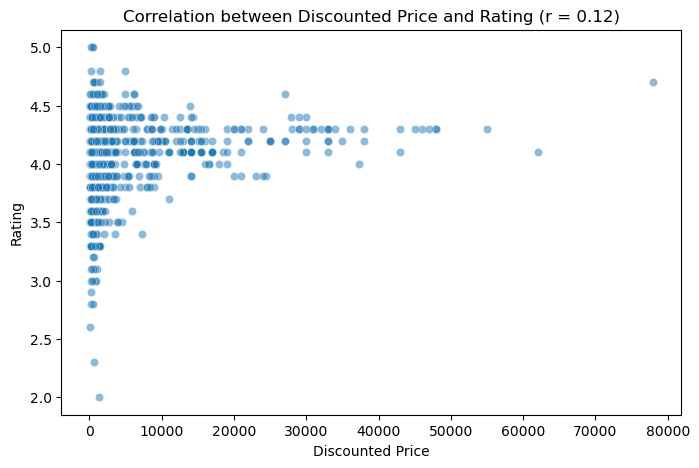

0.12033741712288552

In [102]:
# Ensure discounted_price and rating are numeric
amazon_df["discounted_price"] = pd.to_numeric(amazon_df["discounted_price"], errors="coerce")
amazon_df["rating"] = pd.to_numeric(amazon_df["rating"], errors="coerce")

# Calculate Pearson correlation
correlation = amazon_df["discounted_price"].corr(amazon_df["rating"])

# Scatter plot to visualize the relationship
plt.figure(figsize=(8, 5))
sns.scatterplot(data=amazon_df, x="discounted_price", y="rating", alpha=0.5)

plt.xlabel("Discounted Price")
plt.ylabel("Rating")
plt.title(f"Correlation between Discounted Price and Rating (r = {correlation:.2f})")
plt.show()

# Display correlation value
correlation



####  What are the Top 5 categories based on the highest rating

In [104]:
amazon_df.columns

Index(['product_id', 'product_name', 'category', 'discounted_price',
       'actual_price', 'discount_percentage', 'rating', 'rating_count',
       'about_product', 'user_id', 'user_name', 'review_id', 'review_title',
       'review_content', 'img_link', 'product_link'],
      dtype='object')

In [105]:
most_popular_category= amazon_df.sort_values(by='rating_count',ascending=False)[
    ["category",  "rating"]]

most_popular_category.head(5)

,category,rating
12,"Electronics|HomeTheater,TV&Video|Accessories|C...",4.4
65,"Electronics|HomeTheater,TV&Video|Accessories|C...",4.4
47,"Electronics|HomeTheater,TV&Video|Accessories|C...",4.4
684,"Electronics|HomeTheater,TV&Video|Accessories|C...",4.4
400,"Electronics|Headphones,Earbuds&Accessories|Hea...",4.1


#### Identify any potential areas for improvement or optimization based on the data analysis

1.Pricing Strategy Optimization 
🔹 Finding: No strong correlation (r = 0.12) between discounted_price and rating.
🔹 Improvement:

Conduct category-wise analysis to see if discounts impact ratings differently across product types.
Experiment with dynamic pricing to maximize revenue without over-discounting.

2️ Product Quality & Review Management 
🔹 Finding: Products with high review counts but moderate ratings (4.1-4.4) indicate room for improvement.
🔹 Improvement:

Identify common complaints in reviews to address product flaws.
Encourage more detailed and helpful reviews to boost credibility.
Use sentiment analysis to detect negative feedback trends.

3️ Keyword Optimization for Listings 
🔹 Finding: Popular product keywords include “wireless,” “Bluetooth,” “USB,” “headphones”.
🔹 Improvement:

Enhance product titles & descriptions by incorporating trending keywords.
Optimize SEO strategies for better search visibility.
Remove redundant or weak keywords that don’t contribute to conversions.

4️ Category-Specific Discount Strategies 
🔹 Finding: Some categories might be more sensitive to discounts than others.
🔹 Improvement:

Identify categories where discounting increases sales without hurting profits.
Use A/B testing to determine optimal discount levels.

5️ Data Cleaning & Processing Efficiency 
🔹 Finding: Encountered data formatting issues (e.g., commas in rating_count, missing values).
🔹 Improvement:

Automate data preprocessing to handle missing/erroneous values.
Improve data consistency to avoid manual corrections.


### EDA - 4
#### Spotify dataset

In [229]:
spotify_df = pd.read_csv(r"../Dataset/spotify.csv")
spotify_df.head(5)

,Artist,Track Name,Popularity,Duration (ms),Track ID
0,Drake,Rich Baby Daddy (feat. Sexyy Red & SZA),92,319191,1yeB8MUNeLo9Ek1UEpsyz6
1,Drake,One Dance,91,173986,1zi7xx7UVEFkmKfv06H8x0
2,Drake,IDGAF (feat. Yeat),90,260111,2YSzYUF3jWqb9YP9VXmpjE
3,Drake,First Person Shooter (feat. J. Cole),88,247444,7aqfrAY2p9BUSiupwk3svU
4,Drake,Jimmy Cooks (feat. 21 Savage),88,218364,3F5CgOj3wFlRv51JsHbxhe


#### Read the dataframe, check null value if present then do the needful, check duplicate row , if present then do the needful

In [231]:
spotify_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Artist         440 non-null    object
 1   Track Name     440 non-null    object
 2   Popularity     440 non-null    int64 
 3   Duration (ms)  440 non-null    int64 
 4   Track ID       440 non-null    object
dtypes: int64(2), object(3)
memory usage: 17.3+ KB


In [245]:
spotify_df.drop_duplicates(inplace=True)
print("Number of duplicate rows:", spotify_df.duplicated().sum())




Number of duplicate rows: 0


There is no null values

Duplicate rows has been deleted

#### What is the distribution of popularity among the tracks in the dataset? Visualize it using a histogram

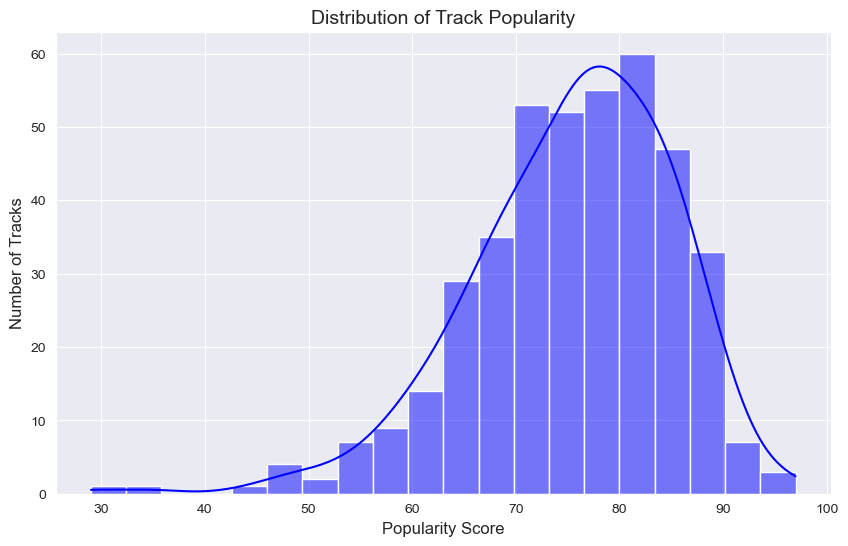

In [247]:
# Set Seaborn style for better visualization
sns.set_style("darkgrid")

# Create histogram
plt.figure(figsize=(10, 6))
sns.histplot(spotify_df["Popularity"], bins=20, kde=True, color="blue")

# Labels and title
plt.xlabel("Popularity Score", fontsize=12)
plt.ylabel("Number of Tracks", fontsize=12)
plt.title("Distribution of Track Popularity", fontsize=14)
plt.show()


####  Is there any relationship between the popularity and the duration of tracks? Explore this using a scatter plot

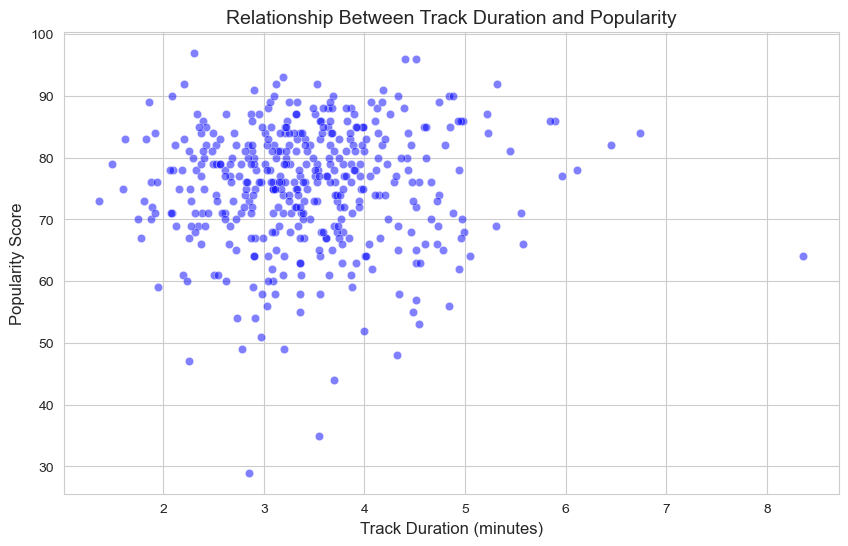

In [249]:
# Set Seaborn style
sns.set_style("whitegrid")

# Convert duration from milliseconds to minutes for better readability
spotify_df["Duration (minutes)"] = spotify_df["Duration (ms)"] / 60000

# Create scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=spotify_df, x="Duration (minutes)", y="Popularity", alpha=0.5, color="blue")

# Labels and title
plt.xlabel("Track Duration (minutes)", fontsize=12)
plt.ylabel("Popularity Score", fontsize=12)
plt.title("Relationship Between Track Duration and Popularity", fontsize=14)
plt.show()


####  Which artist has the highest number of tracks in the dataset? Display the count of tracks for each artist using a countplot

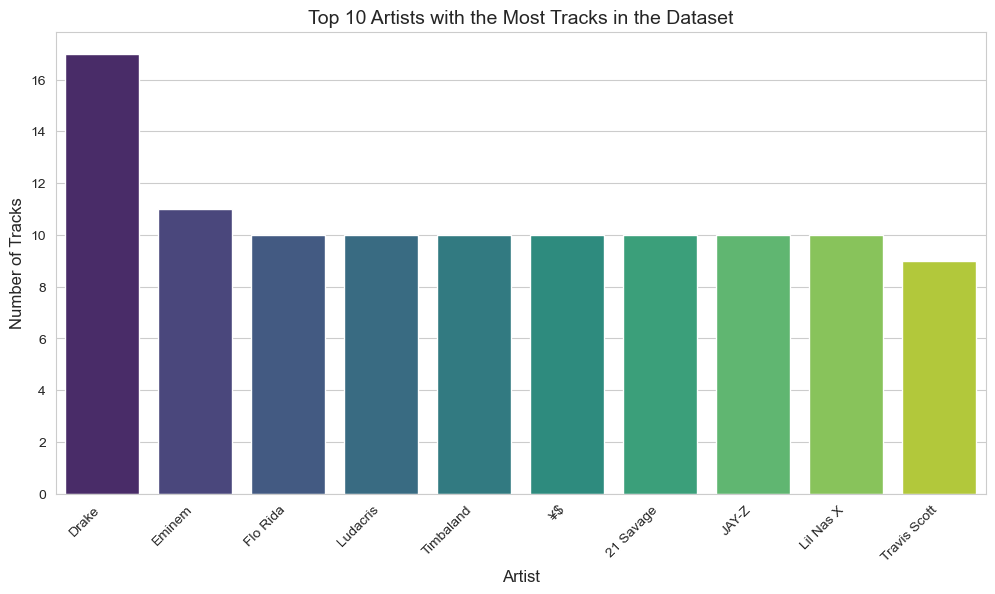

('Drake', 17)

In [251]:
# Count the number of tracks for each artist
artist_counts = spotify_df["Artist"].value_counts()

# Set Seaborn style
sns.set_style("whitegrid")

# Plot countplot for top artists
plt.figure(figsize=(12, 6))
sns.barplot(x=artist_counts.index[:10], y=artist_counts.values[:10], palette="viridis")

# Labels and title
plt.xlabel("Artist", fontsize=12)
plt.ylabel("Number of Tracks", fontsize=12)
plt.title("Top 10 Artists with the Most Tracks in the Dataset", fontsize=14)
plt.xticks(rotation=45, ha="right")  # Rotate x-axis labels for readability
plt.show()

# Display the artist with the highest number of tracks
most_tracks_artist = artist_counts.idxmax()
most_tracks_count = artist_counts.max()
most_tracks_artist, most_tracks_count


#### What are the top 5 least popular tracks in the dataset? Provide the artist name and track name for each

In [253]:
# Get the top 5 least popular tracks
least_popular_tracks = spotify_df.nsmallest(5, "Popularity")[["Artist", "Track Name", "Popularity"]]

# Display the result
least_popular_tracks


,Artist,Track Name,Popularity
207,Pressa,Attachments (feat. Coi Leray),29
231,Justin Bieber,Intentions,35
413,French Montana,Splash Brothers,44
225,Lil Baby,On Me - Remix,47
407,Wyclef Jean,911 (feat. Mary J. Blige),48


####  Among the top 5 most popular artists, which artist has the highest popularity on average? Calculate and display the average popularity for each artist

In [281]:
# Calculate the average popularity for each artist
artist_avg_popularity = spotify_df.groupby("Artist")["Popularity"].mean()

# Get the top 5 artists with the highest total number of tracks
top_5_artists = spotify_df["Artist"].value_counts().head(5).index

# Filter the average popularity for these top 5 artists
top_5_avg_popularity = artist_avg_popularity[top_5_artists].sort_values(ascending=False)

# Display the result
top_5_avg_popularity


Artist
Eminem       83.636364
Drake        82.882353
Flo Rida     78.000000
Timbaland    69.000000
Ludacris     63.000000
Name: Popularity, dtype: float64

#### For the top 5 most popular artists, what are their most popular tracks? List the track name for each artist

In [283]:
# Get the most popular track for each of the top 5 artists
top_tracks = {}

for artist in top_5_avg_popularity.index:
    most_popular_track = spotify_df[spotify_df["Artist"] == artist].nlargest(1, "Popularity")[["Track Name", "Popularity"]]
    top_tracks[artist] = most_popular_track.iloc[0]["Track Name"]

# Convert to a DataFrame for display
top_tracks_df = pd.DataFrame(list(top_tracks.items()), columns=["Artist", "Most Popular Track"])
top_tracks_df


,Artist,Most Popular Track
0,Eminem,Without Me
1,Drake,Rich Baby Daddy (feat. Sexyy Red & SZA)
2,Flo Rida,Low (feat. T-Pain)
3,Timbaland,The Way I Are
4,Ludacris,My Chick Bad


#### Visualize relationships between multiple numerical variables simultaneously using a pair plot

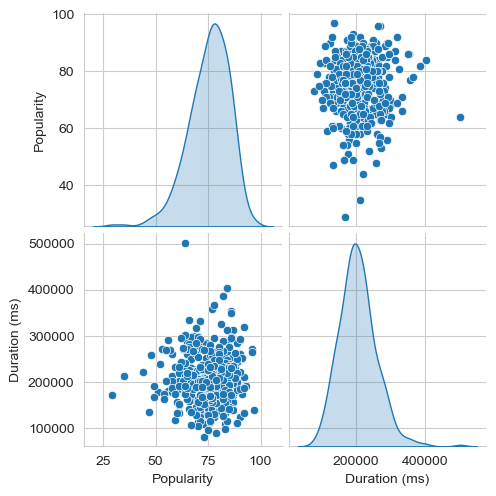

In [285]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select numerical columns for the pair plot
num_cols = ["Popularity", "Duration (ms)"]

# Create the pair plot
sns.pairplot(spotify_df[num_cols], diag_kind="kde")

# Show the plot
plt.show()


####  Does the duration of tracks vary significantly across different artists? Explore this visually using a box plot or violin plot

#### How does the distribution of track popularity vary for different artists? Visualize this using a swarm plot or a violin plot

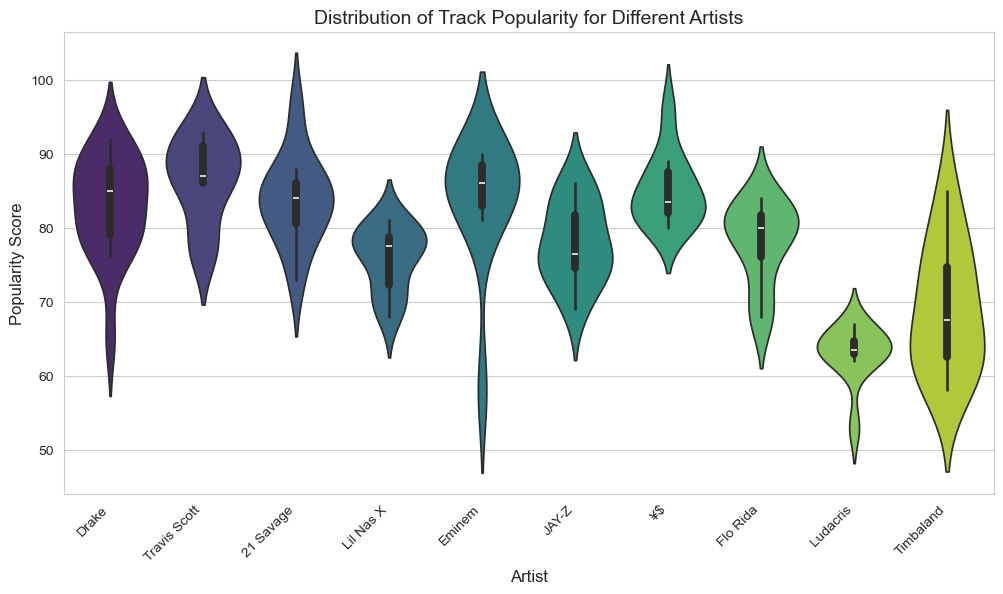

In [289]:


# Select the top 10 artists with the most tracks
top_artists = spotify_df["Artist"].value_counts().head(10).index

# Filter dataset for only these top artists
filtered_df = spotify_df[spotify_df["Artist"].isin(top_artists)]

# Set figure size and style
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

# Create a violin plot to visualize popularity distribution for each artist
sns.violinplot(data=filtered_df, x="Artist", y="Popularity", palette="viridis")

# Labels and title
plt.xticks(rotation=45, ha="right")  # Rotate x-axis labels for readability
plt.xlabel("Artist", fontsize=12)
plt.ylabel("Popularity Score", fontsize=12)
plt.title("Distribution of Track Popularity for Different Artists", fontsize=14)

# Show the plot
plt.show()
